In [6]:
import numpy as np
import pandas as pd

In [9]:
df = pd.read_csv('whitewine_quality.csv')

In [10]:
df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [12]:
label = df.pop('quality')

In [13]:
label

0       6
1       6
2       6
3       6
4       6
       ..
4893    6
4894    5
4895    6
4896    7
4897    6
Name: quality, Length: 4898, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(df,label,train_size=0.7,random_state=100)

In [15]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state = 42)

In [16]:
dtc.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [17]:
y_train_pred = dtc.predict(X_test)

In [18]:
y_train_pred

array([7, 5, 5, ..., 5, 5, 5], dtype=int64)

In [19]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

precision_metric = precision_score(y_test, y_train_pred, average = "macro")
recall_metric = recall_score(y_test, y_train_pred, average = "macro")
f1_metric = f1_score(y_test, y_train_pred, average = "macro")
accuracy_metric = accuracy_score(y_test, y_train_pred)

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [20]:
print("Precision Score: ",precision_metric)
print("Recall Score: ", recall_metric)
print("F1 Score: ", f1_metric)
print("Accuracy Score: ",accuracy_metric)

Precision Score:  0.36909135265794735
Recall Score:  0.38318755650307723
F1 Score:  0.37505622753433604
Accuracy Score:  0.6163265306122448


In [29]:
confusion_matrix(y_test, y_train_pred)

array([[  0,   1,   3,   2,   1,   0,   0],
       [  2,  16,  19,   5,   3,   0,   0],
       [  0,  16, 276,  98,  14,   4,   0],
       [  0,  12, 151, 439,  76,  17,   0],
       [  0,   2,  20,  76, 154,  13,   0],
       [  0,   0,   3,  15,   9,  21,   0],
       [  0,   1,   0,   0,   0,   1,   0]], dtype=int64)

In [30]:
cnf_mx = confusion_matrix(y_test, y_train_pred)

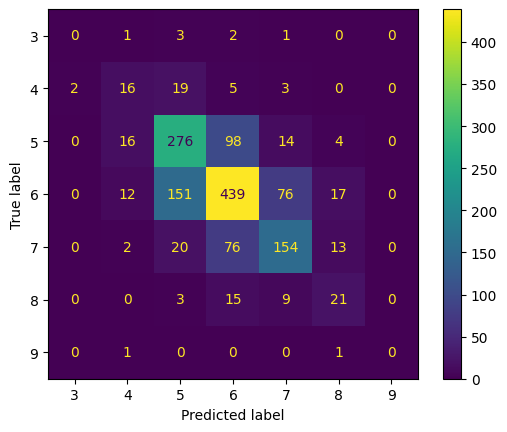

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cnf_mx, display_labels=dtc.classes_)
disp.plot()
plt.show()